# Phase-5: Clustering into Priority Tiers

**Goal:** Group London LSOAs into actionable priority tiers based on policing demand.

**Structure:**
- **5a. Optimal k selection:** K-Means with silhouette scores (k=2 to 6)
- **5b. GMM comparison:** Gaussian Mixture Models with AIC/BIC to cross-validate k
- **5c. Cluster profiling:** Characterise each tier by crime type, deprivation, footfall

**Outputs saved to:** `outputs/phase5/`
- `phase5_clusters.parquet`. LSOA-level cluster assignments
- `phase5_cluster_profiles.csv`. summary statistics per cluster
- `5a_silhouette.png`, `5b_gmm_criteria.png`, `5c_cluster_profiles.png`, `5c_map.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import MinMaxScaler
import geopandas as gpd

print('Imports OK')

Imports OK


In [ ]:
# Dataset
BASE = Path('Dataset')
P4   = BASE / 'outputs' / 'phase4'
OUT  = BASE / 'outputs' / 'phase5'
OUT.mkdir(parents=True, exist_ok=True)

# Cluster colours (Tier 1 = highest risk)
TIER_COLOURS = {
    1: '#D62728',  # red
    2: '#FF7F0E',  # orange
    3: '#2CA02C',  # green
    4: '#1F77B4',  # blue
    5: '#9467BD',  # purple
}

print('Output folder:', OUT)

Output folder: C:\Users\mbeck\OneDrive\Documents\CBL-16_data\outputs\phase5


## Section-1: Load Data

In [3]:
risk = pd.read_parquet(P4 / 'phase4_risk_scores.parquet')
print(f'Loaded: {risk.shape}')
print(f'Columns: {risk.columns.tolist()}')
print(f'Nulls: {risk.isnull().sum().sum()}')
risk.head(3)

Loaded: (4994, 14)
Columns: ['lsoa21cd', 'lsoa21nm', 'lad22nm', 'crime_count', 'risk_score', 'risk_score_scaled', 'nb_predicted', 'nb_ratio', 'severity_weighted_count', 'seasonal_volatility', 'stop_search_rate', 'employment_deprivation', 'resolution_rate', 'total_footfall']
Nulls: 0


,lsoa21cd,lsoa21nm,lad22nm,crime_count,risk_score,risk_score_scaled,nb_predicted,nb_ratio,severity_weighted_count,seasonal_volatility,stop_search_rate,employment_deprivation,resolution_rate,total_footfall
0,E01000011,Barking and Dagenham 016C,Barking and Dagenham,219.0,0.493753,52.58,295.357638,0.741474,38015.0,2.768731,1615.1513,22253,7.82,0.0
1,E01000046,Barking and Dagenham 017D,Barking and Dagenham,323.0,0.507960,54.10,392.744585,0.822417,51544.0,5.140873,128.6223,24419,14.36,0.0
2,E01000051,Barking and Dagenham 021D,Barking and Dagenham,331.0,0.496431,52.87,420.308349,0.787517,50527.0,4.125030,1140.5846,16707,6.47,0.0


In [4]:
# Clustering features: risk score + all validated features
CLUSTER_FEATURES = [
    'risk_score_scaled',
    'severity_weighted_count',
    'seasonal_volatility',
    'stop_search_rate',
    'employment_deprivation',
    'resolution_rate',
    'total_footfall',
]

# Min-max normalise all clustering features to [0,1]
scaler = MinMaxScaler()
X = pd.DataFrame(
    scaler.fit_transform(risk[CLUSTER_FEATURES]),
    columns=CLUSTER_FEATURES,
    index=risk.index
)

print('Clustering matrix shape:', X.shape)
print('Feature ranges (should all be 0-1):')
print(X.agg(['min','max']).round(3))

Clustering matrix shape: (4994, 7)
Feature ranges (should all be 0-1):
     risk_score_scaled  severity_weighted_count  seasonal_volatility  \
min                0.0                      0.0                  0.0   
max                1.0                      1.0                  1.0   

     stop_search_rate  employment_deprivation  resolution_rate  total_footfall  
min               0.0                     0.0              0.0             0.0  
max               1.0                     1.0              1.0             1.0  


## 5a. Optimal k Selection: K-Means + Silhouette

In [5]:
print('Testing K-Means for k=2 to 6...')
k_range = range(2, 7)
inertias   = []
silhouettes = []
km_models  = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X)
    inertia = km.inertia_
    sil     = silhouette_score(X, labels)
    inertias.append(inertia)
    silhouettes.append(sil)
    km_models[k] = (km, labels)
    print(f'  k={k}  inertia={inertia:.1f}  silhouette={sil:.4f}')

best_k_sil = k_range[np.argmax(silhouettes)]
print(f'\nBest k by silhouette: {best_k_sil}')

Testing K-Means for k=2 to 6...


  k=2  inertia=155.4  silhouette=0.5318
  k=3  inertia=106.7  silhouette=0.4217
  k=4  inertia=89.1  silhouette=0.3576
  k=5  inertia=80.9  silhouette=0.3646
  k=6  inertia=73.2  silhouette=0.3116

Best k by silhouette: 2


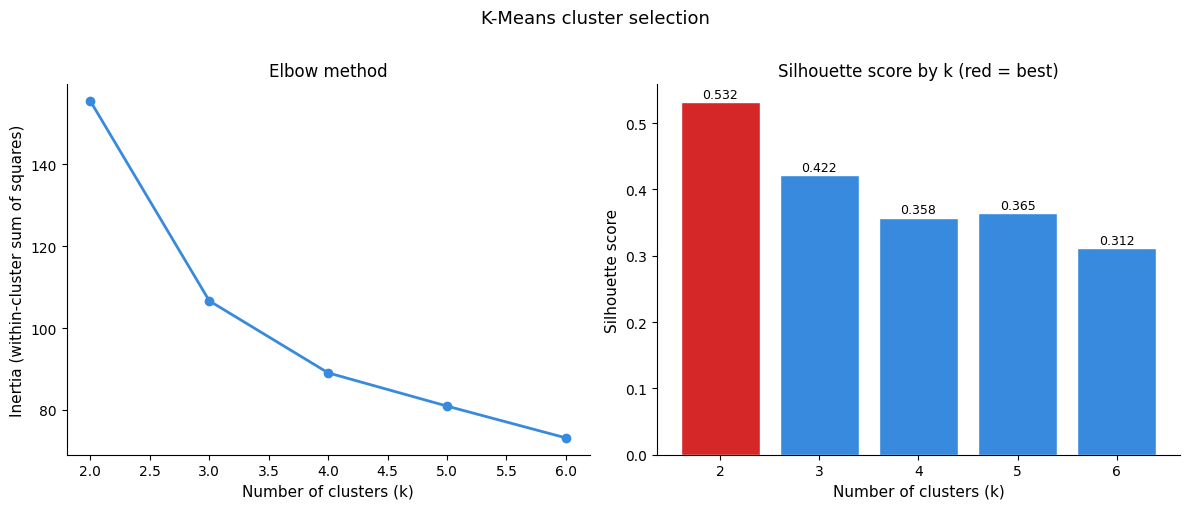

Saved: 5a_silhouette.png


In [6]:
# Plot elbow + silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
axes[0].plot(list(k_range), inertias, 'o-', color='#378ADD', linewidth=2)
axes[0].set_xlabel('Number of clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (within-cluster sum of squares)', fontsize=11)
axes[0].set_title('Elbow method', fontsize=12)
axes[0].spines[['top','right']].set_visible(False)

# Silhouette
colours = ['#D62728' if k == best_k_sil else '#378ADD' for k in k_range]
bars = axes[1].bar(list(k_range), silhouettes, color=colours, edgecolor='white')
axes[1].set_xlabel('Number of clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette score', fontsize=11)
axes[1].set_title('Silhouette score by k (red = best)', fontsize=12)
axes[1].spines[['top','right']].set_visible(False)
for bar, sil in zip(bars, silhouettes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{sil:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('K-Means cluster selection', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT / '5a_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5a_silhouette.png')

## 5b. GMM Comparison: AIC/BIC

In [7]:
print('Fitting Gaussian Mixture Models for k=2 to 6...')
aics = []
bics = []
gmm_models = {}

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5, max_iter=300)
    gmm.fit(X)
    aic = gmm.aic(X)
    bic = gmm.bic(X)
    aics.append(aic)
    bics.append(bic)
    gmm_models[k] = gmm
    print(f'  k={k}  AIC={aic:.1f}  BIC={bic:.1f}')

best_k_aic = k_range[np.argmin(aics)]
best_k_bic = k_range[np.argmin(bics)]
print(f'\nBest k by AIC: {best_k_aic}')
print(f'Best k by BIC: {best_k_bic}')

Fitting Gaussian Mixture Models for k=2 to 6...
  k=2  AIC=-174243.6  BIC=-173781.0
  k=3  AIC=-184755.5  BIC=-184058.3
  k=4  AIC=-197769.5  BIC=-196837.7
  k=5  AIC=-203299.2  BIC=-202132.8
  k=6  AIC=-206217.9  BIC=-204816.9

Best k by AIC: 6
Best k by BIC: 6


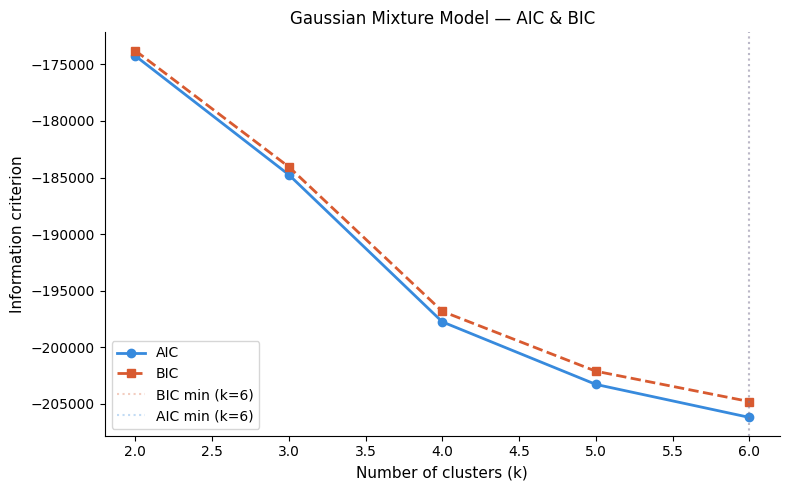

Saved: 5b_gmm_criteria.png


In [8]:
# Plot AIC/BIC
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), aics, 'o-', color='#378ADD', linewidth=2, label='AIC')
ax.plot(list(k_range), bics, 's--', color='#D85A30', linewidth=2, label='BIC')
ax.axvline(best_k_bic, color='#D85A30', alpha=0.3, linestyle=':', label=f'BIC min (k={best_k_bic})')
ax.axvline(best_k_aic, color='#378ADD', alpha=0.3, linestyle=':', label=f'AIC min (k={best_k_aic})')
ax.set_xlabel('Number of clusters (k)', fontsize=11)
ax.set_ylabel('Information criterion', fontsize=11)
ax.set_title('Gaussian Mixture Model — AIC & BIC', fontsize=12)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / '5b_gmm_criteria.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5b_gmm_criteria.png')

In [ ]:
# Select final k
# Decision: take the k that both methods agree on, or prefer interpretability
votes = [best_k_sil, best_k_aic, best_k_bic]
from collections import Counter
vote_counts = Counter(votes)
FINAL_K = vote_counts.most_common(1)[0][0]

# If no majority, default to silhouette (most direct measure of cluster quality)
if vote_counts.most_common(1)[0][1] == 1:
    FINAL_K = best_k_sil

print(f'Silhouette best k: {best_k_sil}')
print(f'AIC best k:        {best_k_aic}')
print(f'BIC best k:        {best_k_bic}')
print(f'\n>>> FINAL k = {FINAL_K} <<<')

# Assign final K-Means labels
final_km, final_labels = km_models[FINAL_K]
risk['cluster_raw'] = final_labels  # 0-indexed

Silhouette best k: 2
AIC best k:        6
BIC best k:        6

>>> FINAL k = 6 <<<


In [10]:
# Re-label clusters as Tier 1 (highest risk) to Tier k (lowest risk)
# based on mean risk_score_scaled per cluster
cluster_mean_risk = (
    risk.groupby('cluster_raw')['risk_score_scaled']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
cluster_mean_risk['tier'] = range(1, FINAL_K + 1)
tier_map = dict(zip(cluster_mean_risk['cluster_raw'], cluster_mean_risk['tier']))

risk['tier'] = risk['cluster_raw'].map(tier_map)

print('Cluster → Tier mapping (by mean risk score):')
print(cluster_mean_risk)
print()
print('LSOAs per tier:')
print(risk['tier'].value_counts().sort_index())

Cluster → Tier mapping (by mean risk score):
   cluster_raw  risk_score_scaled  tier
0            1          62.255423     1
1            3          55.915736     2
2            4          54.124575     3
3            2          51.894595     4
4            5          49.884057     5
5            0          47.392557     6

LSOAs per tier:
tier
1     142
2    1100
3    1246
4     975
5     737
6     794
Name: count, dtype: int64


## 5c. Cluster Profiling

In [11]:
# Profile each tier across all features
PROFILE_COLS = [
    'risk_score_scaled', 'crime_count',
    'severity_weighted_count', 'seasonal_volatility',
    'stop_search_rate', 'employment_deprivation',
    'resolution_rate', 'total_footfall',
]

profile = risk.groupby('tier')[PROFILE_COLS].agg(['mean','median','std']).round(2)
print('--- Cluster Profiles ---')
print(profile.to_string())

# Flat version for export
profile_flat = risk.groupby('tier')[PROFILE_COLS].mean().round(2)
profile_flat['n_lsoas'] = risk.groupby('tier').size()
profile_flat['pct_london'] = (profile_flat['n_lsoas'] / len(risk) * 100).round(1)
profile_flat = profile_flat.reset_index()
print('\n--- Flat Profile (mean per tier) ---')
print(profile_flat.to_string(index=False))

--- Cluster Profiles ---
     risk_score_scaled              crime_count                  severity_weighted_count                      seasonal_volatility               stop_search_rate                   employment_deprivation                   resolution_rate              total_footfall                    
                  mean median   std        mean  median      std                    mean    median        std                mean median    std             mean   median      std                   mean   median      std            mean median   std           mean median          std
tier                                                                                                                                                                                                                                                                                       
1                62.26  61.28  7.14     2777.67  1468.5  5181.39               229814.64  158862.5  289379.81              

In [12]:
# Top boroughs per tier
print('--- Top Boroughs per Tier ---')
for tier in sorted(risk['tier'].unique()):
    top_boros = (
        risk[risk['tier'] == tier]
        .groupby('lad22nm')['risk_score_scaled']
        .mean()
        .sort_values(ascending=False)
        .head(5)
    )
    print(f'\nTier {tier}:')
    for boro, score in top_boros.items():
        n = len(risk[(risk['tier'] == tier) & (risk['lad22nm'] == boro)])
        print(f'  {boro:<25} mean_risk={score:.1f}  n_lsoas={n}')

--- Top Boroughs per Tier ---

Tier 1:
  Westminster               mean_risk=70.7  n_lsoas=9
  City of London            mean_risk=70.7  n_lsoas=2
  Kingston upon Thames      mean_risk=65.9  n_lsoas=1
  Newham                    mean_risk=65.2  n_lsoas=6
  Havering                  mean_risk=65.1  n_lsoas=3

Tier 2:
  Brent                     mean_risk=57.0  n_lsoas=56
  Haringey                  mean_risk=57.0  n_lsoas=58
  Newham                    mean_risk=56.7  n_lsoas=53
  Kensington and Chelsea    mean_risk=56.7  n_lsoas=20
  Tower Hamlets             mean_risk=56.7  n_lsoas=64

Tier 3:
  Westminster               mean_risk=57.0  n_lsoas=18
  Camden                    mean_risk=55.8  n_lsoas=24
  Islington                 mean_risk=55.6  n_lsoas=41
  Tower Hamlets             mean_risk=55.5  n_lsoas=35
  Hounslow                  mean_risk=55.3  n_lsoas=47

Tier 4:
  Westminster               mean_risk=56.0  n_lsoas=9
  Camden                    mean_risk=54.9  n_lsoas=24
  Bar

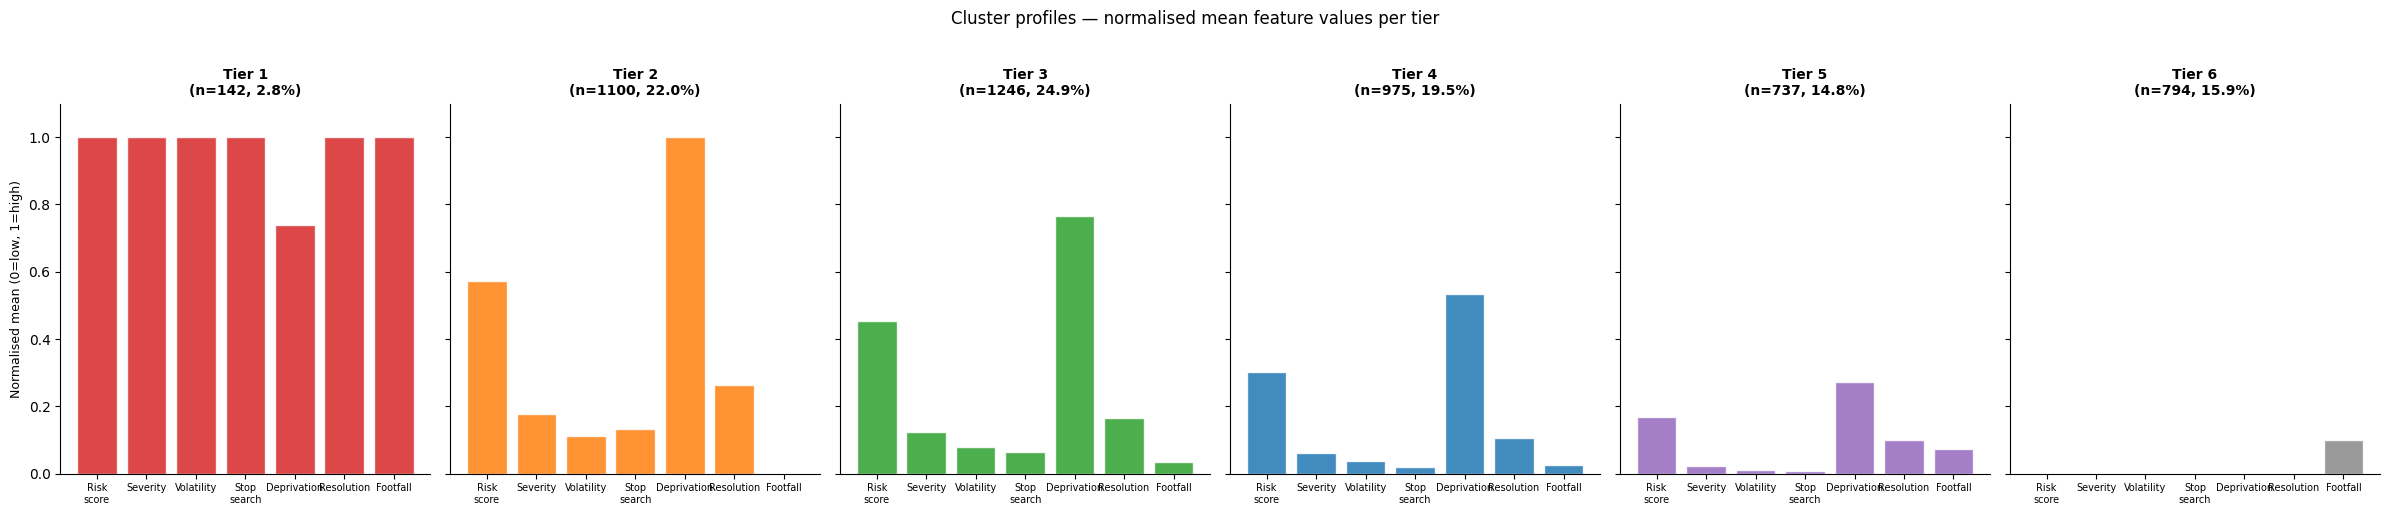

Saved: 5c_cluster_profiles.png


In [13]:
# Profile radar / bar chart
plot_cols = ['risk_score_scaled','severity_weighted_count','seasonal_volatility',
             'stop_search_rate','employment_deprivation','resolution_rate','total_footfall']

# Normalise profile means to [0,1] for fair visual comparison
profile_norm = profile_flat.set_index('tier')[plot_cols].copy()
profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

fig, axes = plt.subplots(1, FINAL_K, figsize=(4 * FINAL_K, 5), sharey=True)
if FINAL_K == 1:
    axes = [axes]

short_labels = ['Risk\nscore', 'Severity', 'Volatility', 'Stop\nsearch',
                'Deprivation', 'Resolution', 'Footfall']

for tier, ax in zip(sorted(profile_norm.index), axes):
    colour = TIER_COLOURS.get(tier, '#888888')
    vals = profile_norm.loc[tier].values
    bars = ax.bar(short_labels, vals, color=colour, edgecolor='white', alpha=0.85)
    n = int(profile_flat.loc[profile_flat['tier'] == tier, 'n_lsoas'].values[0])
    pct = profile_flat.loc[profile_flat['tier'] == tier, 'pct_london'].values[0]
    ax.set_title(f'Tier {tier}\n(n={n}, {pct}%)', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', labelsize=7)
    ax.spines[['top','right']].set_visible(False)
    if tier == 1:
        ax.set_ylabel('Normalised mean (0=low, 1=high)', fontsize=9)

plt.suptitle('Cluster profiles — normalised mean feature values per tier', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / '5c_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5c_cluster_profiles.png')

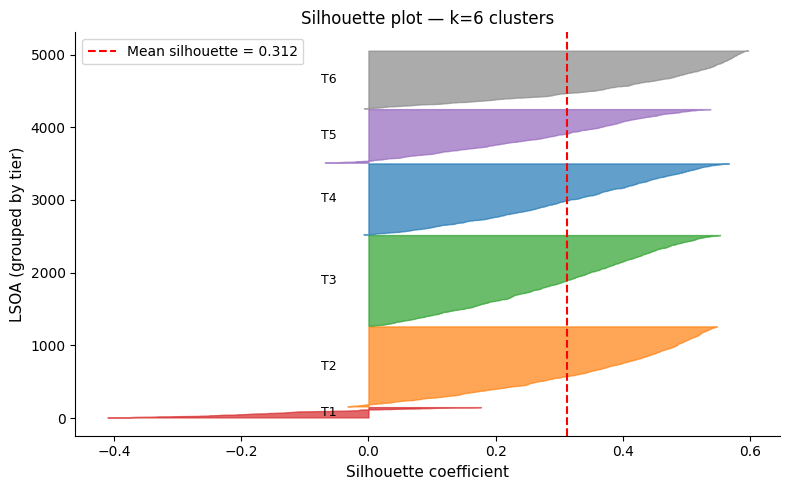

Saved: 5a_silhouette_detail.png


In [14]:
# Silhouette plot for final k
from sklearn.metrics import silhouette_samples
sil_vals = silhouette_samples(X, final_labels)
risk['silhouette'] = sil_vals

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for tier in sorted(risk['tier'].unique()):
    colour = TIER_COLOURS.get(tier, '#888888')
    mask = risk['tier'] == tier
    tier_sil = np.sort(sil_vals[mask.values])
    size = tier_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, tier_sil,
                     facecolor=colour, edgecolor=colour, alpha=0.7)
    ax.text(-0.05, y_lower + size/2, f'T{tier}', ha='right', va='center', fontsize=9)
    y_lower = y_upper + 10

overall_sil = silhouette_score(X, final_labels)
ax.axvline(overall_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean silhouette = {overall_sil:.3f}')
ax.set_xlabel('Silhouette coefficient', fontsize=11)
ax.set_ylabel('LSOA (grouped by tier)', fontsize=11)
ax.set_title(f'Silhouette plot — k={FINAL_K} clusters', fontsize=12)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / '5a_silhouette_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5a_silhouette_detail.png')

## Section-2: Choropleth Map

In [15]:
# Load London LSOA shapefiles
SHP_DIR = BASE / 'LB_shp'
shp_files = list(SHP_DIR.rglob('*.shp'))
print(f'Found {len(shp_files)} shapefiles')

gdf_parts = [gpd.read_file(f) for f in shp_files]
gdf = pd.concat(gdf_parts, ignore_index=True)
print(f'GeoDataFrame shape: {gdf.shape}')
print(f'CRS: {gdf.crs}')
print(f'Columns: {gdf.columns.tolist()}')

Found 33 shapefiles
GeoDataFrame shape: (4994, 7)
CRS: EPSG:27700
Columns: ['lsoa21cd', 'lsoa21nm', 'msoa21cd', 'msoa21nm', 'lad22cd', 'lad22nm', 'geometry']


In [16]:
# Merge tier assignments onto geometry
gdf_merged = gdf.merge(
    risk[['lsoa21cd', 'tier', 'risk_score_scaled']],
    on='lsoa21cd',
    how='left'
)
print(f'Merged GDF shape: {gdf_merged.shape}')
print(f'Unmatched LSOAs: {gdf_merged["tier"].isnull().sum()}')

# Convert to WGS84 for display
gdf_merged = gdf_merged.to_crs(epsg=4326)

Merged GDF shape: (4994, 9)
Unmatched LSOAs: 0


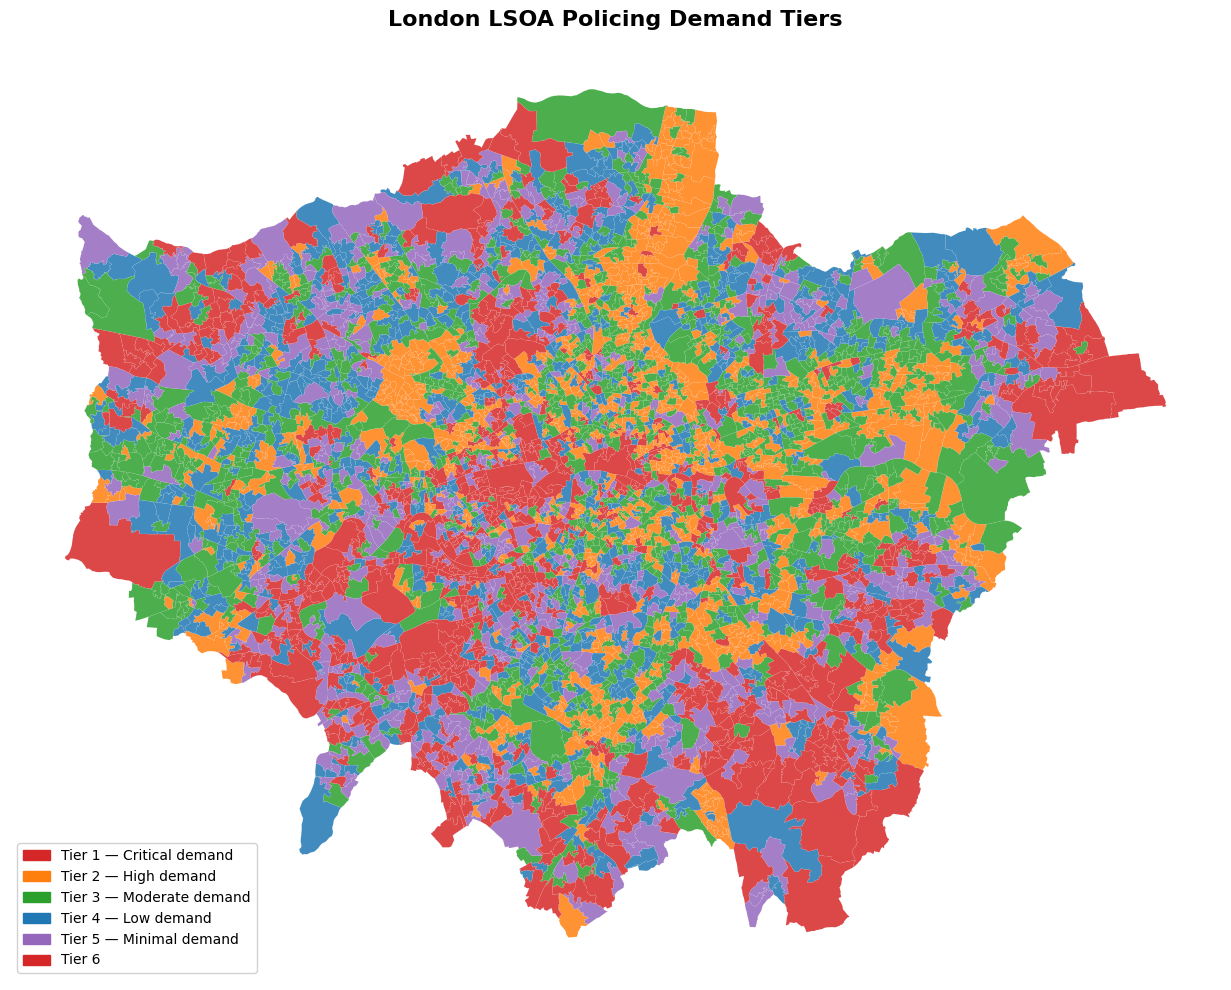

Saved: 5c_map.png


In [17]:
# Static choropleth map
fig, ax = plt.subplots(figsize=(14, 10))

fallback_colours = ['#D62728','#FF7F0E','#2CA02C','#1F77B4','#9467BD']
tiers_sorted = sorted(risk['tier'].unique())

for i, tier in enumerate(tiers_sorted):
    colour = TIER_COLOURS.get(int(tier), fallback_colours[i % len(fallback_colours)])
    gdf_merged[gdf_merged['tier'] == tier].plot(
        ax=ax, color=colour, linewidth=0.05, edgecolor='white', alpha=0.85
    )

# Unmatched LSOAs in grey (only plot if any exist)
unmatched = gdf_merged[gdf_merged['tier'].isnull()]
if len(unmatched) > 0:
    unmatched.plot(ax=ax, color='#cccccc', linewidth=0.05, edgecolor='white')

tier_labels = {
    1: 'Tier 1 — Critical demand',
    2: 'Tier 2 — High demand',
    3: 'Tier 3 — Moderate demand',
    4: 'Tier 4 — Low demand',
    5: 'Tier 5 — Minimal demand',
}
patches = [
    mpatches.Patch(
        color=TIER_COLOURS.get(int(t), fallback_colours[i % len(fallback_colours)]),
        label=tier_labels.get(int(t), f'Tier {int(t)}')
    )
    for i, t in enumerate(tiers_sorted)
]
ax.legend(handles=patches, loc='lower left', fontsize=10, framealpha=0.9)

ax.set_title('London LSOA Policing Demand Tiers', fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT / '5c_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5c_map.png')

## Section-3: Save Outputs


## Section-4: Forced k=4 Solution

In [18]:
K4 = 4
km4 = KMeans(n_clusters=K4, random_state=42, n_init=20, max_iter=500)
labels4 = km4.fit_predict(X)
sil4 = silhouette_score(X, labels4)
sil4_samples = silhouette_samples(X, labels4)

risk4 = risk[['lsoa21cd','lsoa21nm','lad22nm','crime_count',
              'severity_weighted_count','seasonal_volatility','stop_search_rate',
              'employment_deprivation','resolution_rate','total_footfall',
              'risk_score_scaled','nb_predicted','nb_ratio']].copy()
risk4['cluster_raw'] = labels4
risk4['silhouette']  = sil4_samples

# Re-label: Tier 1 = highest mean risk
cluster_mean4 = (
    risk4.groupby('cluster_raw')['risk_score_scaled']
    .mean().sort_values(ascending=False).reset_index()
)
cluster_mean4['tier'] = range(1, K4 + 1)
tier_map4 = dict(zip(cluster_mean4['cluster_raw'], cluster_mean4['tier']))
risk4['tier'] = risk4['cluster_raw'].map(tier_map4)

print(f'k=4  silhouette={sil4:.4f}')
print()
print('LSOAs per tier:')
print(risk4['tier'].value_counts().sort_index())
print()
print('Mean silhouette per tier:')
print(risk4.groupby('tier')['silhouette'].mean().round(4))
print()
print('Mean risk score per tier:')
print(risk4.groupby('tier')['risk_score_scaled'].mean().round(2))

k=4  silhouette=0.3576

LSOAs per tier:
tier
1    1429
2    1538
3    1047
4     980
Name: count, dtype: int64

Mean silhouette per tier:
tier
1    0.3656
2    0.3113
3    0.3238
4    0.4545
Name: silhouette, dtype: float64

Mean risk score per tier:
tier
1    56.02
2    53.80
3    50.85
4    47.68
Name: risk_score_scaled, dtype: float64


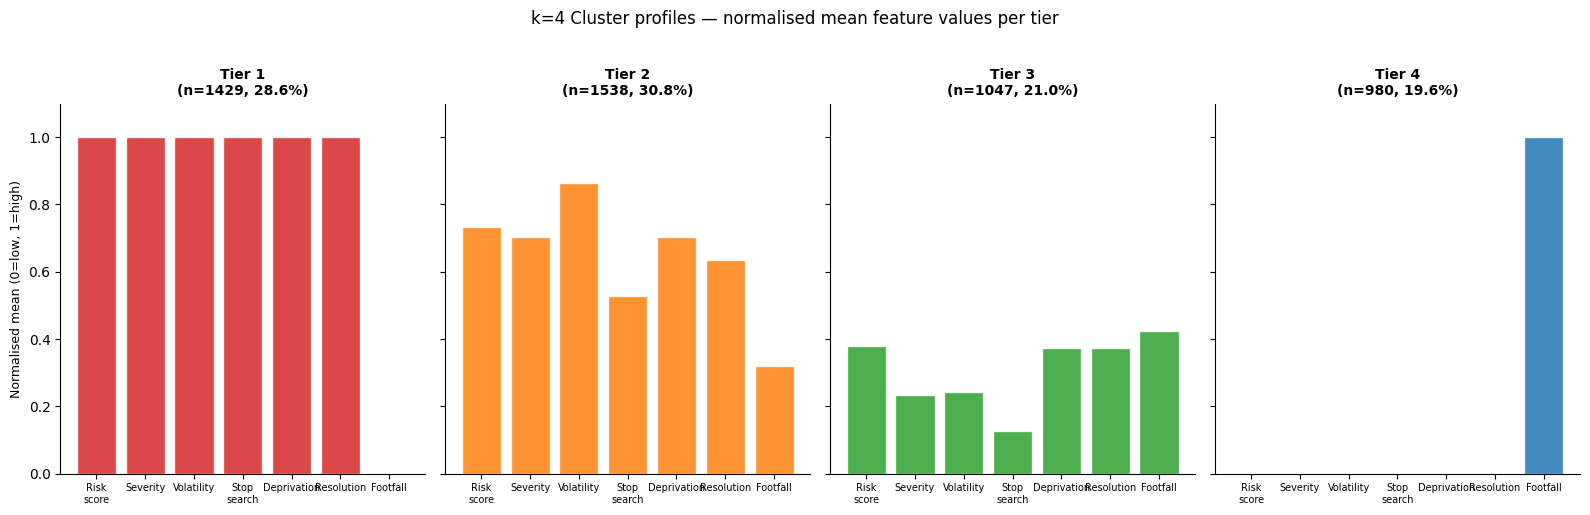

Saved: 5d_k4_cluster_profiles.png


In [19]:
TIER4_COLOURS = {1: '#D62728', 2: '#FF7F0E', 3: '#2CA02C', 4: '#1F77B4'}
TIER4_LABELS  = {
    1: 'Tier 1 — Critical demand',
    2: 'Tier 2 — High demand',
    3: 'Tier 3 — Moderate demand',
    4: 'Tier 4 — Low demand',
}

PROFILE_COLS = ['risk_score_scaled','crime_count','severity_weighted_count',
                'seasonal_volatility','stop_search_rate','employment_deprivation',
                'resolution_rate','total_footfall']

profile4 = risk4.groupby('tier')[PROFILE_COLS].mean().round(2)
profile4['n_lsoas']    = risk4.groupby('tier').size()
profile4['pct_london'] = (profile4['n_lsoas'] / len(risk4) * 100).round(1)
profile4 = profile4.reset_index()

# --- Profile bar charts ---
plot_cols = ['risk_score_scaled','severity_weighted_count','seasonal_volatility',
             'stop_search_rate','employment_deprivation','resolution_rate','total_footfall']
short_labels = ['Risk\nscore','Severity','Volatility','Stop\nsearch',
                'Deprivation','Resolution','Footfall']

profile4_norm = profile4.set_index('tier')[plot_cols].copy()
profile4_norm = (profile4_norm - profile4_norm.min()) / (profile4_norm.max() - profile4_norm.min())

fig, axes = plt.subplots(1, K4, figsize=(4 * K4, 5), sharey=True)
for tier, ax in zip(range(1, K4 + 1), axes):
    colour = TIER4_COLOURS[tier]
    vals = profile4_norm.loc[tier].values
    ax.bar(short_labels, vals, color=colour, edgecolor='white', alpha=0.85)
    n   = int(profile4.loc[profile4['tier'] == tier, 'n_lsoas'].values[0])
    pct = profile4.loc[profile4['tier'] == tier, 'pct_london'].values[0]
    ax.set_title(f'Tier {tier}\n(n={n}, {pct}%)', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', labelsize=7)
    ax.spines[['top','right']].set_visible(False)
    if tier == 1:
        ax.set_ylabel('Normalised mean (0=low, 1=high)', fontsize=9)

plt.suptitle('k=4 Cluster profiles — normalised mean feature values per tier', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / '5d_k4_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5d_k4_cluster_profiles.png')

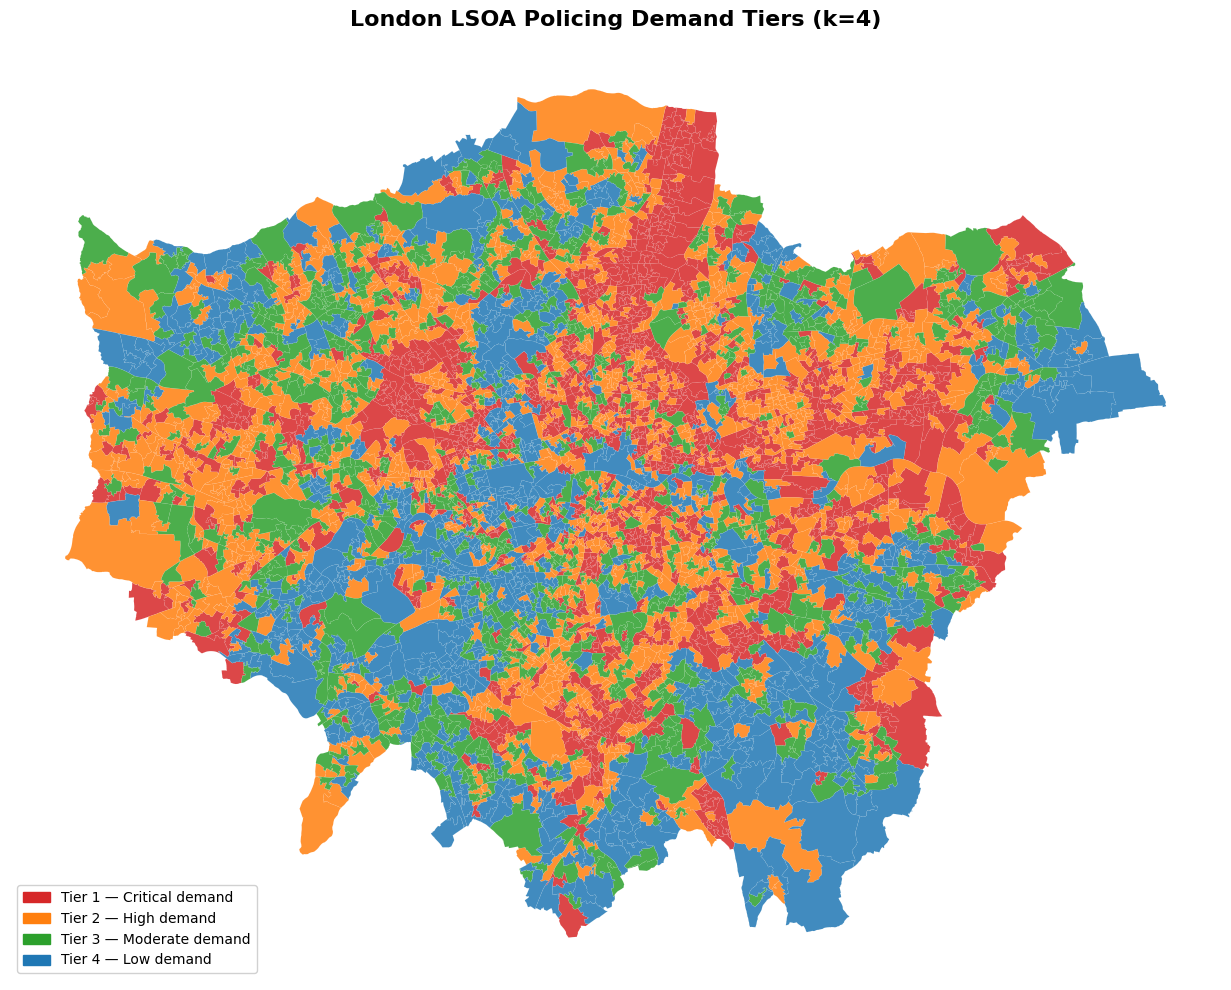

Saved: 5d_k4_map.png


In [ ]:
# k=4 choropleth map
gdf_k4 = gdf.merge(risk4[['lsoa21cd','tier','risk_score_scaled']], on='lsoa21cd', how='left')
gdf_k4 = gdf_k4.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(14, 10))
for tier in range(1, K4 + 1):
    gdf_k4[gdf_k4['tier'] == tier].plot(
        ax=ax, color=TIER4_COLOURS[tier], linewidth=0.05, edgecolor='white', alpha=0.85
    )
unmatched4 = gdf_k4[gdf_k4['tier'].isnull()]
if len(unmatched4) > 0:
    unmatched4.plot(ax=ax, color='#cccccc', linewidth=0.05, edgecolor='white')

patches4 = [mpatches.Patch(color=TIER4_COLOURS[t], label=TIER4_LABELS[t]) for t in range(1, K4 + 1)]
ax.legend(handles=patches4, loc='lower left', fontsize=10, framealpha=0.9)
ax.set_title('London LSOA Policing Demand Tiers (k=4)', fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT / '5d_k4_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5d_k4_map.png')

In [21]:
# Save k=4 outputs
risk4[['lsoa21cd','lsoa21nm','lad22nm','tier','risk_score_scaled','crime_count',
       'severity_weighted_count','seasonal_volatility','stop_search_rate',
       'employment_deprivation','resolution_rate','total_footfall',
       'silhouette']].to_parquet(OUT / 'phase5_clusters_k4.parquet', index=False)
print(f'Saved phase5_clusters_k4.parquet — {risk4.shape}')

profile4.to_csv(OUT / 'phase5_cluster_profiles_k4.csv', index=False)
print(f'Saved phase5_cluster_profiles_k4.csv')

print()
print('=== k=4 SUMMARY ===')
print(f'Silhouette score (k=4): {sil4:.4f}  |  (k={FINAL_K}): {overall_sil:.4f}')
print()
for _, row in profile4.iterrows():
    print(f"  Tier {int(row['tier'])}: {int(row['n_lsoas'])} LSOAs ({row['pct_london']}%)  mean_risk={row['risk_score_scaled']:.1f}  mean_crimes={row['crime_count']:.0f}")

Saved phase5_clusters_k4.parquet — (4994, 16)
Saved phase5_cluster_profiles_k4.csv

=== k=4 SUMMARY ===
Silhouette score (k=4): 0.3576  |  (k=6): 0.3116

  Tier 1: 1429 LSOAs (28.6%)  mean_risk=56.0  mean_crimes=638
  Tier 2: 1538 LSOAs (30.8%)  mean_risk=53.8  mean_crimes=601
  Tier 3: 1047 LSOAs (21.0%)  mean_risk=50.9  mean_crimes=446
  Tier 4: 980 LSOAs (19.6%)  mean_risk=47.7  mean_crimes=413


In [22]:
# Save LSOA-level cluster assignments
cluster_out = risk[['lsoa21cd','lsoa21nm','lad22nm','tier',
                     'risk_score_scaled','crime_count',
                     'severity_weighted_count','seasonal_volatility',
                     'stop_search_rate','employment_deprivation',
                     'resolution_rate','total_footfall',
                     'silhouette']].copy()
cluster_out.to_parquet(OUT / 'phase5_clusters.parquet', index=False)
print(f'Saved phase5_clusters.parquet — {cluster_out.shape}')

# Save cluster profiles
profile_flat.to_csv(OUT / 'phase5_cluster_profiles.csv', index=False)
print(f'Saved phase5_cluster_profiles.csv — {profile_flat.shape}')

Saved phase5_clusters.parquet — (4994, 13)
Saved phase5_cluster_profiles.csv — (6, 11)


In [23]:
print('=' * 55)
print('PHASE 5 SUMMARY')
print('=' * 55)
print(f'Total LSOAs:               {len(risk)}')
print(f'Final k (tiers):           {FINAL_K}')
print(f'Silhouette score (k={FINAL_K}):   {overall_sil:.4f}')
print(f'Best k — silhouette:       {best_k_sil}')
print(f'Best k — AIC:              {best_k_aic}')
print(f'Best k — BIC:              {best_k_bic}')
print()
print('LSOAs per tier:')
for _, row in profile_flat.iterrows():
    print(f"  Tier {int(row['tier'])}: {int(row['n_lsoas'])} LSOAs ({row['pct_london']}%)  mean_risk={row['risk_score_scaled']:.1f}")
print('=' * 55)
print(f'Outputs saved to: {OUT}')

PHASE 5 SUMMARY
Total LSOAs:               4994
Final k (tiers):           6
Silhouette score (k=6):   0.3116
Best k — silhouette:       2
Best k — AIC:              6
Best k — BIC:              6

LSOAs per tier:
  Tier 1: 142 LSOAs (2.8%)  mean_risk=62.3
  Tier 2: 1100 LSOAs (22.0%)  mean_risk=55.9
  Tier 3: 1246 LSOAs (24.9%)  mean_risk=54.1
  Tier 4: 975 LSOAs (19.5%)  mean_risk=51.9
  Tier 5: 737 LSOAs (14.8%)  mean_risk=49.9
  Tier 6: 794 LSOAs (15.9%)  mean_risk=47.4
Outputs saved to: C:\Users\mbeck\OneDrive\Documents\CBL-16_data\outputs\phase5
